# 06. 有限差分法 — グリッド・安定性・CFL・数値拡散

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 3. グリッド |
| Applied | 4. 安定性 〜 7. 陰解法 |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

解析解が無い PDE は **有限差分法 (FDM)** で解きます。空間を格子に切り、微分を差分で置き換える。

$$
\frac{\partial^2 u}{\partial x^2}\Big|_i \approx \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2}
$$

本章の最重要メッセージ:

> **数値解は、刻み幅 $\Delta x$ と時間ステップ $\Delta t$ を間違えると壊れる。**

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import pde_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "pde_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from pde_book import grids, solvers, plotting, datasets

## 3. グリッドと差分

格子点の上で場を表し、隣との差で微分を近似します。`grids` モジュールが格子と
安定性数(拡散数 $r$、CFL 数 $C$)を提供します。

In [3]:
# Grids and the dimensionless numbers that govern explicit stability.
g = grids.Grid1D(0.0, 1.0, 11)
print("x =", g.x)
print("dx =", g.dx)
print("heat number r for (alpha=1, dt=0.004, dx=0.1):",
      grids.heat_number(1.0, 0.004, 0.1), "-> stable?", grids.heat_stable(1.0, 0.004, 0.1))
print("CFL number C for (c=1, dt=0.2, dx=0.1):",
      grids.courant_number(1.0, 0.2, 0.1), "-> ok?", grids.cfl_ok(1.0, 0.2, 0.1))

x = [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
dx = 0.1
heat number r for (alpha=1, dt=0.004, dx=0.1): 0.3999999999999999 -> stable? True
CFL number C for (c=1, dt=0.2, dx=0.1): 2.0 -> ok? False


## 4. 安定性 — 熱方程式の陽解法は $r \le 1/2$ (Applied)

陽的 FTCS 法は、拡散数 $r = \alpha\,\Delta t/\Delta x^2$ が $1/2$ を超えると **発散** します。
同じ初期条件・同じ最終時刻でも、$\Delta t$ を少し変えるだけで結果が天国と地獄です。

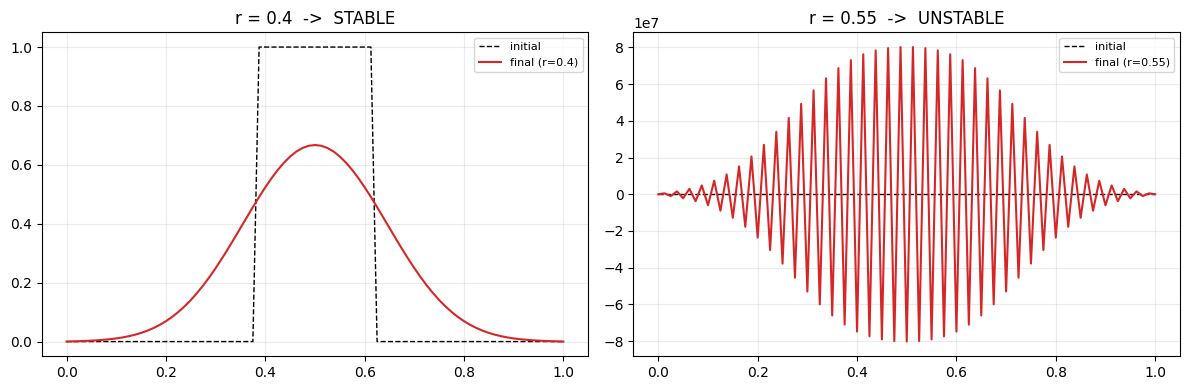

In [4]:
import numpy as np

# Heat FTCS: r <= 1/2 smooths nicely; r > 1/2 explodes into sawtooth oscillations.
g = grids.Grid1D(0.0, 1.0, 81)
x, dx = g.x, g.dx
alpha = 1.0
u0 = datasets.bump(x, 0.5, 0.12)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, r in zip(axes, (0.4, 0.55)):
    dt = r * dx**2 / alpha
    U = solvers.solve_heat_explicit(u0, alpha, dx, dt, steps=120)
    ax.plot(x, U[0], "k--", lw=1, label="initial")
    ax.plot(x, U[-1], color="#d62728", lw=1.5, label=f"final (r={r})")
    ax.set_title(f"r = {r}  ->  {'STABLE' if r <= 0.5 else 'UNSTABLE'}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 5. CFL 条件 — 移流・波動は $C \le 1$

双曲型(移流・波動)では **CFL 条件** $C = c\,\Delta t/\Delta x \le 1$ が安定の鍵。
直感: **1 ステップで波が 1 格子以上進んではいけない**(情報の伝播速度を数値が追い越せない)。

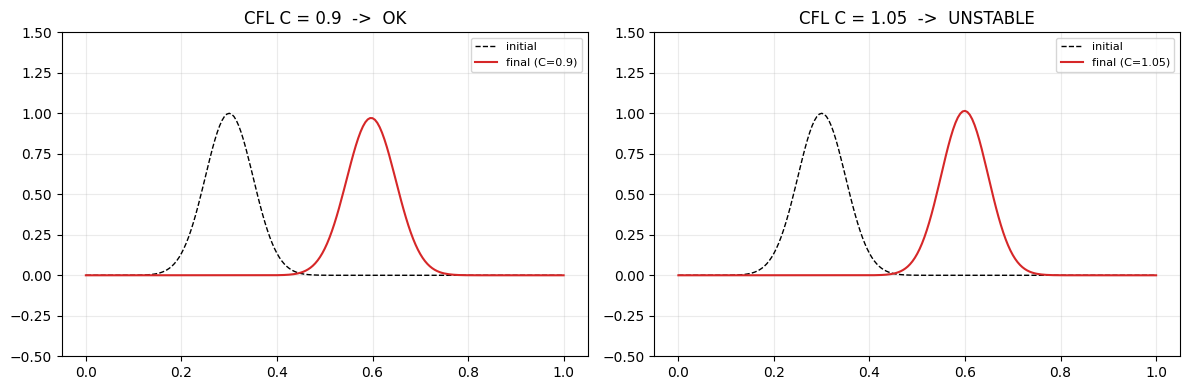

In [5]:
import numpy as np

# Advection upwind: CFL <= 1 transports cleanly; CFL > 1 blows up.
g = grids.Grid1D(0.0, 1.0, 201)
x, dx = g.x, g.dx
c = 1.0
u0 = datasets.gaussian(x, 0.3, 0.05)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, C in zip(axes, (0.9, 1.05)):
    dt = C * dx / c
    steps = int(0.3 / dt)
    U = solvers.solve_transport(u0, c, dx, dt, steps, scheme="upwind")
    ax.plot(x, U[0], "k--", lw=1, label="initial")
    ax.plot(x, U[-1], color="#d62728", lw=1.5, label=f"final (C={C})")
    ax.set_ylim(-0.5, 1.5)
    ax.set_title(f"CFL C = {C}  ->  {'OK' if C <= 1 else 'UNSTABLE'}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### インタラクティブ: 安定数を動かして「壊れる瞬間」を見る(静的 HTML でも動く)

Plotly のスライダーで、熱方程式の拡散数 $r$ と移流の CFL 数 $C$ を動かします。
それぞれ $r>1/2$、$C>1$ を超えた瞬間に数値解が崩れる(振動・発散)ことを体感してください。

In [6]:
import plotly.io as pio
from pde_book import interactive

pio.renderers.default = "plotly_mimetype+notebook_connected"
interactive.plotly_heat_stability().show()      # heat: stable iff r <= 1/2

In [7]:
interactive.plotly_cfl_transport().show()        # advection: stable iff CFL C <= 1

## 6. 数値拡散 — 安定でも「なまる」

風上差分は安定ですが、一次精度ゆえに余分な **数値拡散** が入り、移流させると波形がだんだん **なまり**ます
(本来は形が保たれるはず)。格子を細かくすると軽減します。

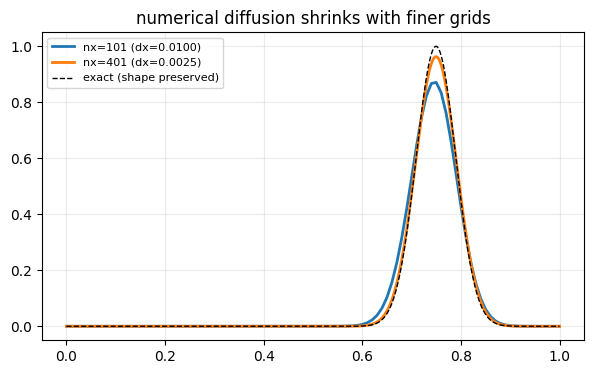

In [8]:
import numpy as np

# Numerical diffusion: upwind preserves the bump's motion but smears its shape.
c = 1.0
fig, ax = plt.subplots(figsize=(7, 4))
for n in (101, 401):
    g = grids.Grid1D(0.0, 1.0, n)
    x, dx = g.x, g.dx
    dt = 0.9 * dx / c
    steps = int(0.5 / dt)
    u0 = datasets.gaussian(x, 0.25, 0.04)
    U = solvers.solve_transport(u0, c, dx, dt, steps, scheme="upwind")
    ax.plot(x, U[-1], lw=2, label=f"nx={n} (dx={dx:.4f})")
ax.plot(g.x, datasets.gaussian(g.x, 0.25 + c * steps * dt, 0.04), "k--", lw=1,
        label="exact (shape preserved)")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
ax.set_title("numerical diffusion shrinks with finer grids")
plt.show()

## 7. 陰解法 — 大きな $\Delta t$ でも安定

陰的(後退 Euler)法は連立一次方程式を毎ステップ解く代わりに、**無条件安定**。
熱方程式を $r=5$($\gg 1/2$、陽解法なら即爆発)で解いても破綻しません。

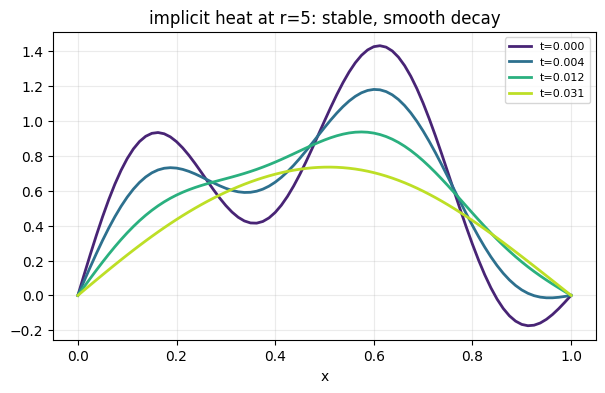

In [9]:
import numpy as np

# Implicit heat is stable even at r = 5 (explicit would explode instantly).
g = grids.Grid1D(0.0, 1.0, 81)
x, dx = g.x, g.dx
alpha = 1.0
dt = 5.0 * dx**2 / alpha
U = solvers.solve_heat_implicit(datasets.sine_combo(x, (1, 4), (1.0, 0.5)), alpha, dx, dt, steps=40)
ax = plotting.plot_field_snapshots(x, U, [0, 5, 15, 40], dt=dt,
                                   title="implicit heat at r=5: stable, smooth decay")
plt.show()

## Exercises

1. 熱方程式の安定限界 $r \le 1/2$ を、モード $\sin(kx)$ の増幅率 $1 - 4r\sin^2(k\Delta x/2)$ から導け。
2. CFL を 1 ちょうどにすると upwind が**数値拡散ゼロ**で正確に移流すること(偶然の一致)を確かめよ。
3. 陰解法の 1 ステップが三重対角系を解くことを確認し、`scipy` の `splu` がそれを高速化することを述べよ。

## Advanced Notes

- **von Neumann 安定性解析**: 解を $u_j^n = \xi^n e^{ikj\Delta x}$ と置き、増幅率 $|\xi|\le 1$ を要求する標準手法。
- **Lax の同値定理**: 適切な問題では「整合性 + 安定性 ⇔ 収束」。だから安定性が死活的。
- **Crank-Nicolson 法**: 陽と陰の中間(時間 2 次精度)で無条件安定。実務の定番。
- **高解像度スキーム**: 移流の数値拡散を抑えつつ振動を防ぐ TVD / WENO などがある。